<a href="https://colab.research.google.com/github/WVF-1/Heuristic-GNN-For-Optimized-Streetlights/blob/main/project5_heuristic_controller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pittsburgh Traffic Flow, Project 5, Part 1: The Hand-Built Adaptive Controller

**Newsletter series: Geospatial Data & Public Transportation — Project 5 of 5 (GNN), Notebook 1 of 3**

Before training any neural network, we need a real, working adaptive baseline -- both as a legitimate standalone comparison against Project 4's fixed timing, and as the "teacher" the GNN will imitate in the next notebook (behavioral cloning), before reinforcement learning lets it improve past this baseline's ceiling.

**What this controller actually does**, in three parts, all working on the exact same graph (signalized intersections as nodes, streets as edges) from Project 4:

1. **Coordination via ETA-triggered green waves.** When a car discharges onto a street heading toward the next signal, that intersection is notified with an estimated time of arrival. It switches to green when the *lead* car of that platoon is ~92% of the way there -- mimicking a real driver who doesn't need to brake for a light that's clearly about to turn.
2. **Actuation via flush-based hold.** Once green, a light holds until ~85% of the queue that arrived during its red phase has cleared -- not a fixed duration.
3. **Max-pressure tie-breaking at the merge.** Where Forbes and Fifth Avenue compete for the same shared lane, priority tilts toward whichever approach currently holds the larger queue.

**The one non-negotiable part: hard min/max green safety valves.** Every rule above is subordinate to a floor (never less than 8 seconds green) and a ceiling (never more than 45 seconds green) -- these are never learned, never adjusted by data, and exist specifically so no approach can be starved indefinitely no matter what the adaptive logic wants.

This is, essentially, a from-scratch version of real deployed systems like SCOOT and SCATS, and the max-pressure piece is a genuine published traffic-signal algorithm, not an invented rule.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

rng = np.random.default_rng(42)

PGH_BLACK = "#1a1a1a"
FIXED_COLOR = "#4a6b8a"
ADAPTIVE_COLOR = "#c1440e"


## Step 1: Controller parameters

Two kinds of numbers here, and they get treated very differently:

- **Hard safety constants** (`MIN_GREEN_TICKS`, `MAX_GREEN_TICKS`): fixed, never touched by any learning process, later or now.
- **Tunable behavior thresholds** (`ETA_TRIGGER_FRAC`, `FLUSH_FRAC`): reasonable starting values here, legitimate candidates for the GNN to adjust later since there's no safety reason they must be exactly 92% or 85%.

In [2]:
CELL_LENGTH_M = 7.5
VMAX = 5
P_SLOW = 0.2
TICK_SECONDS = 1.0

MIN_GREEN_TICKS = 8     # hard safety floor
MAX_GREEN_TICKS = 45    # hard safety ceiling
ETA_TRIGGER_FRAC = 0.92 # switch downstream light when the lead car is ~92% of the way there
FLUSH_FRAC = 0.85       # hold green until ~85% of the arrived queue has cleared


## Step 2: The network

Same Forbes/Fifth Avenue merge network as Project 4 -- eleven signalized intersections, unchanged.

In [3]:
EDGE_LENGTHS_M = {
    "forbes_entry": 300, "forbes_seg1": 250, "forbes_seg2": 280, "forbes_seg3": 220,
    "combined_seg1": 240, "combined_seg2": 260,
    "cross_grant": 100, "cross_smithfield": 100, "cross_wood": 100, "cross_stanwix": 100, "cross_fortpitt": 100,
    "fifth_entry": 300, "fifth_seg1": 240, "fifth_seg2": 260, "fifth_seg3": 230, "fifth_seg4": 250, "fifth_seg5": 200,
    "cross_craig": 100, "cross_bigelow": 100, "cross_bellefield": 100, "cross_halket": 100, "cross_dithridge": 100,
}
ENTRY_EDGES = ["forbes_entry", "fifth_entry"] + [e for e in EDGE_LENGTHS_M if e.startswith("cross_")]

def make_edge(length_m):
    n_cells = max(1, int(round(length_m / CELL_LENGTH_M)))
    return np.full(n_cells, -1, dtype=int), np.full(n_cells, -1, dtype=int)

INTERSECTIONS_SPEC = [
    {"name": "Forbes & Grant St",         "approaches": [("forbes_entry", "forbes_seg1"), ("cross_grant", None)]},
    {"name": "Forbes & Smithfield St",    "approaches": [("forbes_seg1", "forbes_seg2"), ("cross_smithfield", None)]},
    {"name": "Forbes & Wood St",          "approaches": [("forbes_seg2", "forbes_seg3"), ("cross_wood", None)]},
    {"name": "Forbes & Fifth (Merge)",    "approaches": [("forbes_seg3", "combined_seg1"), ("fifth_seg5", "combined_seg1")]},
    {"name": "Forbes & Stanwix St",       "approaches": [("combined_seg1", "combined_seg2"), ("cross_stanwix", None)], "green_ratios": [0.8, 0.2]},
    {"name": "Forbes & Fort Pitt Bridge", "approaches": [("combined_seg2", None), ("cross_fortpitt", None)], "green_ratios": [0.8, 0.2]},
    {"name": "Fifth & Craig St",          "approaches": [("fifth_entry", "fifth_seg1"), ("cross_craig", None)]},
    {"name": "Fifth & Bigelow Blvd",      "approaches": [("fifth_seg1", "fifth_seg2"), ("cross_bigelow", None)]},
    {"name": "Fifth & Bellefield Ave",    "approaches": [("fifth_seg2", "fifth_seg3"), ("cross_bellefield", None)]},
    {"name": "Fifth & Halket St",         "approaches": [("fifth_seg3", "fifth_seg4"), ("cross_halket", None)]},
    {"name": "Fifth & Dithridge St",      "approaches": [("fifth_seg4", "fifth_seg5"), ("cross_dithridge", None)]},
]


## Step 3: The Nagel-Schreckenberg step

Same as Project 4. Worth noting explicitly: there's no separate saturation-headway gate here. While debugging Project 4's merge capacity, we found the cellular automaton has its own physical ceiling on sustained discharge (driven by how fast a stopped car can actually accelerate away) -- roughly 0.44 vehicles/tick regardless of any headway assumption layered on top. So this engine relies on that natural ceiling directly rather than adding an extra, redundant parameter that wouldn't change the result.

In [4]:
def ns_step(speeds, car_ids, vmax, p_slow, boundary_open, rng):
    n = len(speeds)
    occupied = np.where(speeds >= 0)[0]
    if len(occupied) == 0:
        return speeds, car_ids, None

    new_speeds = np.full(n, -1, dtype=int)
    new_car_ids = np.full(n, -1, dtype=int)
    exited_id = None

    positions = sorted(occupied.tolist())
    next_pos = {p: (positions[i + 1] if i + 1 < len(positions) else None) for i, p in enumerate(positions)}

    for pos in sorted(positions, reverse=True):
        v = speeds[pos]
        cid = car_ids[pos]
        nxt = next_pos[pos]
        gap = (nxt - pos - 1) if nxt is not None else (999 if boundary_open else (n - 1 - pos))

        v = min(v + 1, vmax)
        v = min(v, gap)
        if v > 0 and rng.random() < p_slow:
            v = max(v - 1, 0)

        new_pos = pos + v
        if new_pos >= n:
            if boundary_open:
                exited_id = cid
                continue
            new_pos = n - 1
            v = new_pos - pos
        new_speeds[new_pos] = v
        new_car_ids[new_pos] = cid

    return new_speeds, new_car_ids, exited_id


## Step 4: The controller itself

Each intersection tracks: which approach is currently green, how long it's been green, how many cars have cleared since this phase started (for the flush check), and any pending ETA countdown from an upstream neighbor's announcement.

One deliberate design choice worth flagging: `request_green()` only accepts a new countdown if none is already running. Without this, every car in a sustained platoon would re-announce itself and keep resetting the timer back to full -- meaning the trigger would actually fire based on the *last* car of a platoon instead of the *lead* car, which is the opposite of what we want.

In [5]:
class ActuatedIntersection:
    def __init__(self, spec):
        self.name = spec["name"]
        self.approaches = spec["approaches"]
        self.is_merge = spec["approaches"][0][1] == spec["approaches"][1][1] and spec["approaches"][0][1] is not None
        self.current_phase = 0
        self.ticks_in_phase = 0
        self.queue_at_phase_start = [0, 0]
        self.discharged_this_phase = [0, 0]
        self.pending_eta = None

    def request_green(self, approach_idx, eta_ticks):
        """Called by an upstream neighbor announcing a car is coming. Only the
        LEAD car of an incoming platoon should set the countdown -- later cars
        in the same platoon must not keep resetting it."""
        if approach_idx != self.current_phase and self.pending_eta is None:
            self.pending_eta = eta_ticks

    def step(self, queue_len_by_approach, t):
        self.ticks_in_phase += 1
        cur = self.current_phase
        other = 1 - cur

        cleared_frac = 1.0
        if self.queue_at_phase_start[cur] > 0:
            cleared_frac = self.discharged_this_phase[cur] / self.queue_at_phase_start[cur]

        must_hold = self.ticks_in_phase < MIN_GREEN_TICKS
        must_switch_maxout = self.ticks_in_phase >= MAX_GREEN_TICKS
        flush_done = cleared_frac >= FLUSH_FRAC and queue_len_by_approach[cur] == 0

        eta_trigger = False
        if self.pending_eta is not None:
            self.pending_eta -= 1
            if self.pending_eta <= 0:
                eta_trigger = True

        # Max-pressure tie-break at the merge only
        pressure_wants_switch = self.is_merge and queue_len_by_approach[other] > queue_len_by_approach[cur] * 1.3

        should_switch = (not must_hold) and (must_switch_maxout or flush_done or eta_trigger or pressure_wants_switch)

        if should_switch:
            self.current_phase = other
            self.ticks_in_phase = 0
            self.queue_at_phase_start[other] = queue_len_by_approach[other]
            self.discharged_this_phase[other] = 0
            self.pending_eta = None
            return True
        return False

    def is_green(self, approach_idx):
        return approach_idx == self.current_phase


def estimate_eta_ticks(edge_length_m):
    """Rough time for a car entering an edge to reach its far end. A simplification
    worth naming honestly: this uses a fixed assumed cruise speed based on edge
    length, not that specific car's actual speed at the moment it discharged."""
    n_cells = max(1, int(round(edge_length_m / CELL_LENGTH_M)))
    cruise_speed = VMAX * 0.8
    return int(n_cells / cruise_speed)


## Step 5: Run the simulation

Same arrival rates and 30-minute run length as Project 4, so the comparison is apples-to-apples. We log per-tick state (queue lengths, signal phase, and whether each intersection switched) in the same run used for the stats below -- running it twice with a shared random generator would make the reported numbers and the exported data quietly disagree with each other.

In [6]:
def run_heuristic_simulation(n_ticks, log_training_data=False):
    edges = {name: make_edge(length) for name, length in EDGE_LENGTHS_M.items()}
    intersections = {spec["name"]: ActuatedIntersection(spec) for spec in INTERSECTIONS_SPEC}
    edge_owner = {}
    for spec in INTERSECTIONS_SPEC:
        for a_idx, (edge_in, edge_out) in enumerate(spec["approaches"]):
            edge_owner[edge_in] = (spec["name"], a_idx)

    LAMBDA_FORBES_ENTRY, LAMBDA_FIFTH_ENTRY, LAMBDA_CROSS = 0.20, 0.15, 0.10
    queue_log = {name: [] for name in EDGE_LENGTHS_M}
    spawn_tick, wait_times, n_in_system_log = {}, [], []
    next_car_id = 0
    training_rows = [] if log_training_data else None

    for t in range(n_ticks):
        for name in ENTRY_EDGES:
            speeds, ids = edges[name]
            lam = LAMBDA_FORBES_ENTRY if name == "forbes_entry" else (LAMBDA_FIFTH_ENTRY if name == "fifth_entry" else LAMBDA_CROSS)
            if speeds[0] < 0 and rng.poisson(lam) > 0:
                speeds[0], ids[0] = VMAX, next_car_id
                spawn_tick[next_car_id] = t
                next_car_id += 1

        current_queues = {name: int(np.sum(edges[name][0] == 0)) for name in EDGE_LENGTHS_M}

        switched = {}
        for spec in INTERSECTIONS_SPEC:
            inter = intersections[spec["name"]]
            q0 = current_queues[spec["approaches"][0][0]]
            q1 = current_queues[spec["approaches"][1][0]]
            switched[spec["name"]] = inter.step([q0, q1], t)

        if log_training_data:
            row = {"tick": t}
            for name in EDGE_LENGTHS_M:
                row[f"queue_{name}"] = current_queues[name]
            for spec in INTERSECTIONS_SPEC:
                inter = intersections[spec["name"]]
                row[f"phase_{spec['name']}"] = inter.current_phase
                row[f"switched_{spec['name']}"] = int(switched[spec["name"]])
            training_rows.append(row)

        for spec in INTERSECTIONS_SPEC:
            inter = intersections[spec["name"]]
            for a_idx, (edge_in, edge_out) in enumerate(spec["approaches"]):
                speeds, ids = edges[edge_in]
                green = inter.is_green(a_idx)
                downstream_ok = edges[edge_out][0][0] < 0 if edge_out is not None else True
                boundary_open = green and downstream_ok
                new_speeds, new_ids, exited = ns_step(speeds, ids, VMAX, P_SLOW, boundary_open, rng)
                edges[edge_in] = (new_speeds, new_ids)
                if exited is not None:
                    inter.discharged_this_phase[a_idx] += 1
                    if edge_out is not None:
                        ds, di = edges[edge_out]
                        ds[0], di[0] = VMAX, exited
                        if edge_out in edge_owner:
                            down_name, down_approach = edge_owner[edge_out]
                            eta = estimate_eta_ticks(EDGE_LENGTHS_M[edge_out])
                            trigger_tick = max(1, int(eta * ETA_TRIGGER_FRAC))
                            intersections[down_name].request_green(down_approach, trigger_tick)
                    else:
                        wait_times.append(t - spawn_tick.pop(exited))

        for name in EDGE_LENGTHS_M:
            queue_log[name].append(int(np.sum(edges[name][0] == 0)))
        n_in_system_log.append(len(spawn_tick))

    return {"queue_log": queue_log, "wait_times": wait_times, "n_in_system_log": n_in_system_log,
            "total_spawned": next_car_id, "training_rows": training_rows}

N_TICKS_STATS = 1800  # 30 minutes -- matches Project 4
results = run_heuristic_simulation(N_TICKS_STATS, log_training_data=True)

print(f"Total spawned: {results['total_spawned']}")
print(f"Trips completed: {len(results['wait_times'])}")


Total spawned: 2260
Trips completed: 2224


## Visual 1: Validating against Little's Law

Same check as every previous simulation notebook -- a real validation, not a cosmetic one.

Average wait time: 24.04 s
L (measured): 30.52   lambda x W (predicted): 30.19
Ratio: 1.011


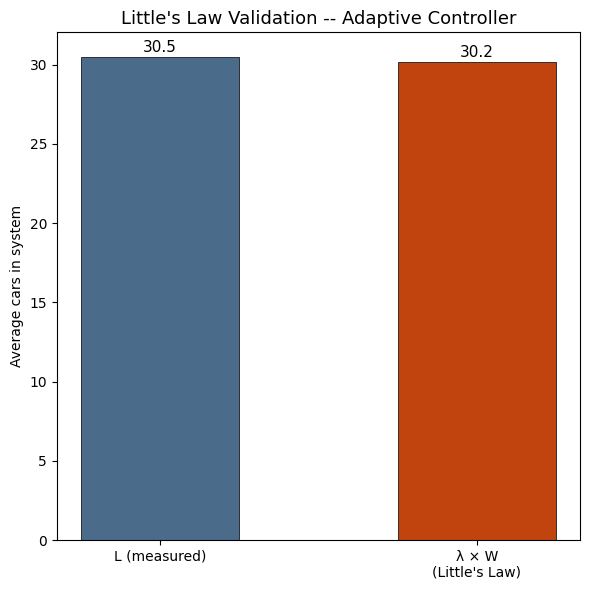

In [7]:
avg_wait_s = np.mean(results["wait_times"]) * TICK_SECONDS
avg_n_in_system = np.mean(results["n_in_system_log"])
arrival_rate_per_tick = results["total_spawned"] / N_TICKS_STATS

L_measured = avg_n_in_system
L_predicted = arrival_rate_per_tick * (avg_wait_s / TICK_SECONDS)

print(f"Average wait time: {avg_wait_s:.2f} s")
print(f"L (measured): {L_measured:.2f}   lambda x W (predicted): {L_predicted:.2f}")
print(f"Ratio: {L_measured / L_predicted:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(["L (measured)", "λ × W\n(Little's Law)"], [L_measured, L_predicted],
              color=["#4a6b8a", "#c1440e"], edgecolor=PGH_BLACK, linewidth=0.6, width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f"{b.get_height():.1f}", ha="center", fontsize=11)
ax.set_title("Little's Law Validation -- Adaptive Controller", fontsize=13)
ax.set_ylabel("Average cars in system")
plt.tight_layout()
plt.savefig("viz1_littles_law_adaptive.png", dpi=200, bbox_inches="tight")
plt.show()


## Visual 2: Fixed-timing vs. adaptive, head to head

Project 4's fixed-timing simulation (same network, same arrival rates, 30-minute run) produced an average wait of **45.96 seconds** and an average of **58.8 cars** in the system. That's the number this controller needs to beat to justify calling it an improvement, not just a different way of doing the same thing.

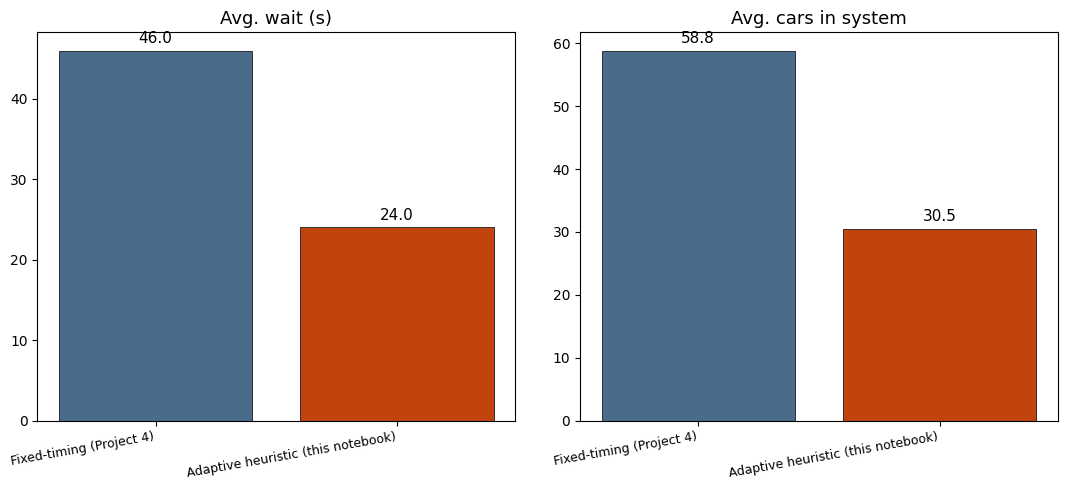

Average wait improved by 48% versus fixed timing.


In [8]:
FIXED_TIMING_AVG_WAIT_S = 45.96
FIXED_TIMING_L = 58.8

comparison = pd.DataFrame({
    "Fixed-timing (Project 4)": [FIXED_TIMING_AVG_WAIT_S, FIXED_TIMING_L],
    "Adaptive heuristic (this notebook)": [avg_wait_s, L_measured],
}, index=["Avg. wait (s)", "Avg. cars in system"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, metric in zip(axes, comparison.index):
    vals = comparison.loc[metric]
    bars = ax.bar(vals.index, vals.values, color=[FIXED_COLOR, ADAPTIVE_COLOR], edgecolor=PGH_BLACK, linewidth=0.6)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(vals.values)*0.02, f"{b.get_height():.1f}", ha="center", fontsize=11)
    ax.set_title(metric, fontsize=13)
    ax.set_xticks(range(len(vals.index)))
    ax.set_xticklabels(vals.index, rotation=10, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("viz2_fixed_vs_adaptive.png", dpi=200, bbox_inches="tight")
plt.show()

pct_improvement = (1 - avg_wait_s / FIXED_TIMING_AVG_WAIT_S) * 100
print(f"Average wait improved by {pct_improvement:.0f}% versus fixed timing.")


## Step 6: Save exports

The per-tick state/action log is exactly the training data Notebook 2 needs for behavioral cloning -- the GNN will learn to reproduce these same phase decisions from the same graph state, before reinforcement learning lets it improve past this ceiling.

In [9]:
training_df = pd.DataFrame(results["training_rows"])
training_df.to_csv("pittsburgh_heuristic_training_data.csv", index=False)

queue_df = pd.DataFrame(results["queue_log"])
queue_df.to_csv("pittsburgh_heuristic_queue_timeseries.csv", index=False)

print("Saved pittsburgh_heuristic_training_data.csv   --", len(training_df), "rows,", len(training_df.columns), "columns")
print("Saved pittsburgh_heuristic_queue_timeseries.csv --", len(queue_df), "rows")


Saved pittsburgh_heuristic_training_data.csv   -- 1800 rows, 45 columns
Saved pittsburgh_heuristic_queue_timeseries.csv -- 1800 rows


In [10]:
from google.colab import files

files.download("pittsburgh_heuristic_training_data.csv")
files.download("pittsburgh_heuristic_queue_timeseries.csv")
files.download("viz1_littles_law_adaptive.png")
files.download("viz2_fixed_vs_adaptive.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recap + what's next

You just built a legitimate, from-scratch version of real deployed adaptive signal control (coordination + actuation + max-pressure, with hard safety valves that are never learned), validated it against Little's Law, and confirmed it substantially beats Project 4's fixed timing on the identical network and demand.

**Notebook 2** trains a GNN to imitate this controller's decisions via behavioral cloning -- the exported training data above is exactly what that needs. **Notebook 3** then fine-tunes that GNN with reinforcement learning against the real delay/throughput/fairness objective, letting it improve past this heuristic's ceiling rather than just matching it.